In [1]:
import numpy as np
import pandas as pd 
from sklearn.preprocessing import StandardScaler

In [2]:
train = pd.read_csv("mall_customers.csv")
train.shape

(200, 5)

In [3]:
train.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
train.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
train.duplicated().sum()

np.int64(0)

In [6]:
train.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## creating a feature from `Spending Score (1-100)`, using thresholds

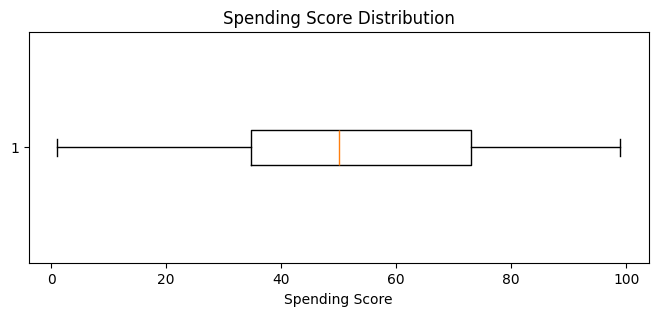

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.boxplot(train["Spending Score (1-100)"], vert=False)

plt.xlabel("Spending Score")
plt.title("Spending Score Distribution")
plt.show()

# creating the preprocessor class

In [8]:
import numpy as np
import pandas as pd


class Preprocessor:
    def __init__(self, df):
        self.df = df.copy()

    def drop_customer_id(self):
        self.df.drop(columns=["CustomerID"], inplace=True)

    def handle_missing_values(self):
        self.df.fillna(0, inplace=True)

    def encode_gender(self):
        self.df["Gender"] = self.df["Gender"].map({
            "Male": 0,
            "Female": 1
        })

    def add_spending_level(self):
        self.df["Spending_Level"] = pd.cut(
            self.df["Spending Score (1-100)"],
            bins=[0, 30, 50, 70, 100],
            labels=[0, 1, 2, 3],
            include_lowest=True
        ).astype(int)

    def add_income_level(self):
        self.df["Income_Level"] = pd.cut(
            self.df["Annual Income (k$)"],
            bins=[0, 40, 70, 100, float("inf")],
            labels=[0, 1, 2, 3]
        ).astype(int)

    def add_income_spending_interaction(self):
        self.df["Income_Spending"] = (
            self.df["Annual Income (k$)"] *
            self.df["Spending Score (1-100)"]
        )

    def add_age_spending_interaction(self):
        self.df["Age_Spending"] = (
            self.df["Age"] *
            self.df["Spending Score (1-100)"]
        )

    def transform(self):
        self.drop_customer_id()
        self.handle_missing_values()
        self.encode_gender()
        self.add_spending_level()
        self.add_income_level()
        self.add_income_spending_interaction()
        self.add_age_spending_interaction()

        return self.df

In [ ]:
%%writefile preprocessor.py

import numpy as np
import pandas as pd

class Preprocessor:
    def __init__(self, df):
        self.df = df.copy()

    def drop_customer_id(self):
        self.df.drop(columns=["CustomerID"], inplace=True)

    def handle_missing_values(self):
        self.df.fillna(0, inplace=True)

    def encode_gender(self):
        self.df["Gender"] = self.df["Gender"].map({
            "Male": 0,
            "Female": 1
        })

    def add_spending_level(self):
        self.df["Spending_Level"] = pd.cut(
            self.df["Spending Score (1-100)"],
            bins=[0, 30, 50, 70, 100],
            labels=[0, 1, 2, 3],
            include_lowest=True
        ).astype(int)

    def add_income_level(self):
        self.df["Income_Level"] = pd.cut(
            self.df["Annual Income (k$)"],
            bins=[0, 40, 70, 100, float("inf")],
            labels=[0, 1, 2, 3]
        ).astype(int)

    def add_income_spending_interaction(self):
        self.df["Income_Spending"] = (
            self.df["Annual Income (k$)"] *
            self.df["Spending Score (1-100)"]
        )

    def add_age_spending_interaction(self):
        self.df["Age_Spending"] = (
            self.df["Age"] *
            self.df["Spending Score (1-100)"]
        )

    def transform(self):
        self.drop_customer_id()
        self.handle_missing_values()
        self.encode_gender()
        self.add_spending_level()
        self.add_income_level()
        self.add_income_spending_interaction()
        self.add_age_spending_interaction()

        return self.df

# finding the best K

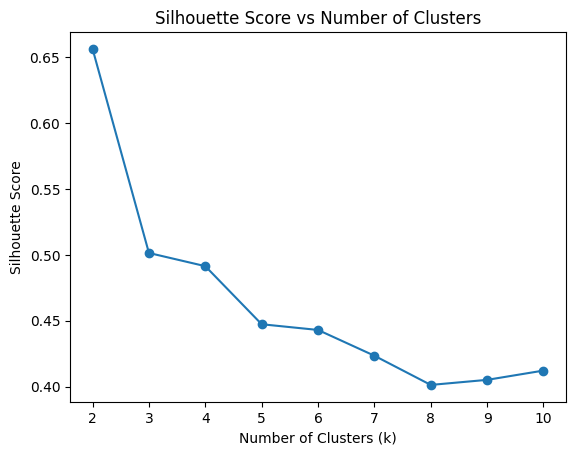

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = Preprocessor(train).transform()

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(k_values)
plt.show()

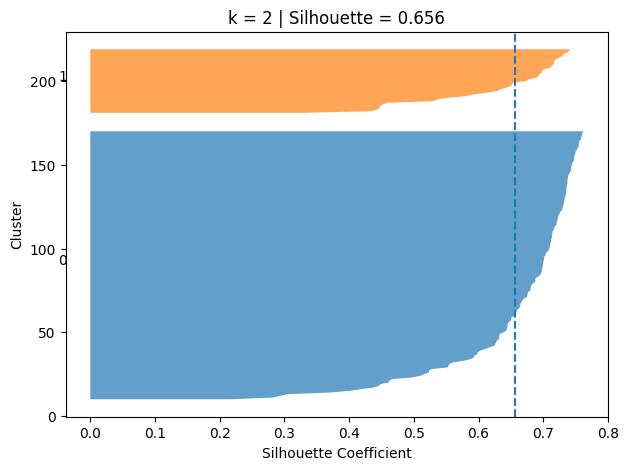

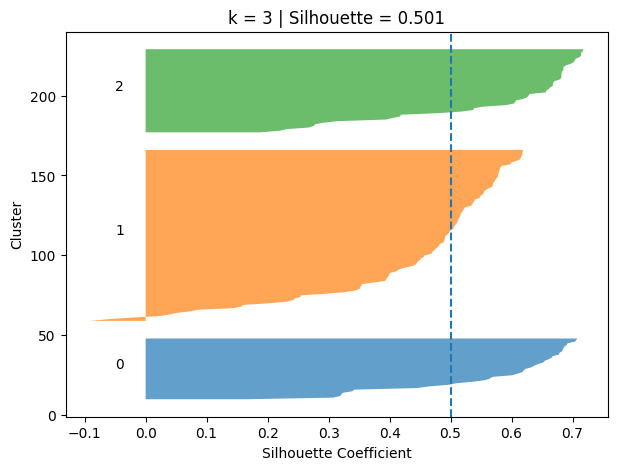

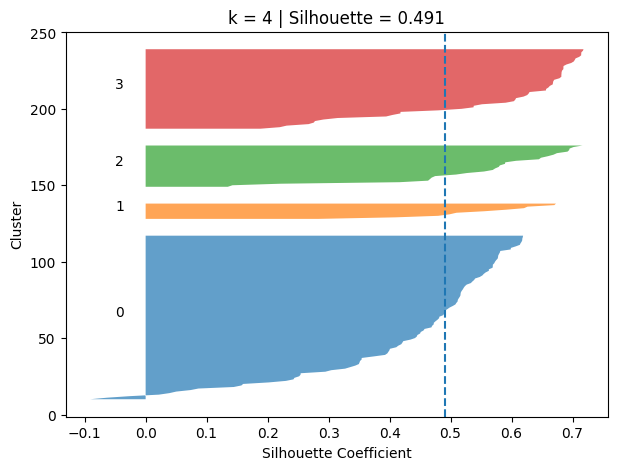

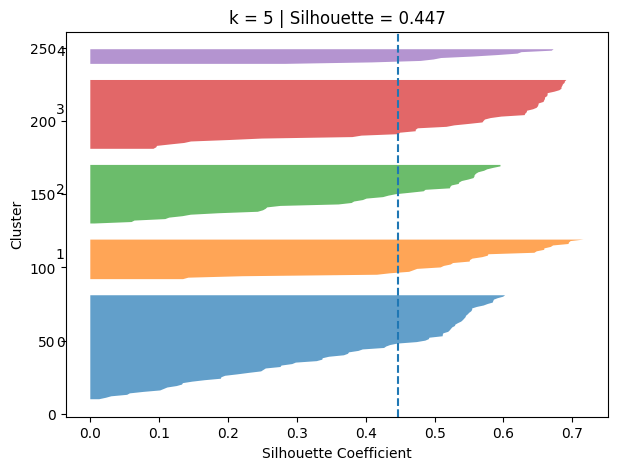

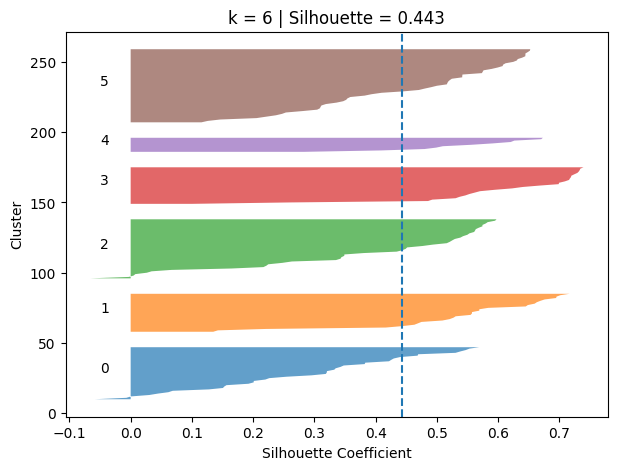

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

X = Preprocessor(train).transform()

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    silhouette_avg = silhouette_score(X, labels)
    silhouette_vals = silhouette_samples(X, labels)

    fig, ax = plt.subplots(figsize=(7, 5))

    y_lower = 10

    for cluster in range(k):

        cluster_vals = silhouette_vals[labels == cluster]
        cluster_vals.sort()

        size = cluster_vals.shape[0]
        y_upper = y_lower + size

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_vals,
            alpha=0.7
        )

        ax.text(-0.05, y_lower + size / 2, str(cluster))

        y_lower = y_upper + 10

    ax.axvline(
        silhouette_avg,
        linestyle="--"
    )

    ax.set_title(f"k = {k} | Silhouette = {silhouette_avg:.3f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")

    plt.show()

In [11]:
best_k = k_values[np.argmax(silhouette_scores)]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))

Best k: 2
Best silhouette score: 0.656099859602772


In [12]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=20,
    random_state=42
)

model.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [13]:
from sklearn.metrics import silhouette_score

labels = model.labels_

sil_score = silhouette_score(X, labels)

print("Silhouette:", sil_score)

Silhouette: 0.656099859602772


In [14]:
submission = pd.DataFrame({
    "segment": model.predict(X)
})

print(submission.shape)
submission.head()

(200, 1)


,segment
0,0
1,0
2,0
3,0
4,0


In [15]:
import zipfile
import joblib

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

joblib.dump(model, 'model')
submission.to_csv('submission.csv', index=False)
file_names = ['mall_customer_segmentation.ipynb', 'submission.csv', 'model', 'preprocessor.py']
compress(file_names)

File Paths:
['mall_customer_segmentation.ipynb', 'submission.csv', 'model', 'preprocessor.py']
